# Losses per Position — CP16/EP16 @ 32k, single-doc (no repro)

Golden cp16/ep16 leaf with `max_seq_len` dropped to 32768, 2 single-doc partitions.
**Result: NO repro.** 3/3 reps clean — single-doc partitions don't express the bug.

- **datum 0** (`random-tile`): 29,999 positions — random 256-token chunk tiled to 30k, prefix=31
- **datum 1** (`mudith-b21i13`): 29,984 positions — real datum (batch 21, idx 13), 29,681-token prompt + 303-token completion
- Logprobs cover the full sequence, but **only supervised positions (weight > 0) have non-zero logprobs** —
  the prompt region is zeroed out by the trainer. So the per-position plots show the full sequence,
  but only the completion band has real loss data.
- The `nlls` field is the **weighted mean over supervised tokens only** — that's the actual loss.
- Each doc is a **single-doc partition** (2×30k docs under a 32k cap can't share a row)
- Run: `min32k_0801_003030/` inside `min32k/`


In [1]:
import gzip, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_DIR = Path('../../../min32k/min32k_0801_003030')
if not RUN_DIR.exists():
    for cand in [Path('../../../experiment_artefacts/glm/lps1003_loss_spikes/min32k/min32k_0801_003030'),
                 Path('../../experiment_artefacts/glm/lps1003_loss_spikes/min32k/min32k_0801_003030')]:
        if cand.exists():
            RUN_DIR = cand
            break
RUN_DIR = RUN_DIR.resolve()

N_REPS = 3
DATUM_LABELS = ['random-tile', 'mudith-b21i13']

# Completion bands (supervised span where loss weight > 0)
SUPERVISED = {
    0: {'start': 31, 'end': 29998, 'n': 29968},       # random-tile: almost all supervised
    1: {'start': 29681, 'end': 29983, 'n': 303},       # mudith: 303-token completion at tail
}

reps = {}
for r in range(N_REPS):
    p = RUN_DIR / f'min32k_window_rep{r}.json.gz'
    reps[r] = json.load(gzip.open(p))
    print(f"rep{r}: nlls={[f'{x:.6f}' for x in reps[r]['nlls']]}  destroyed={reps[r]['destroyed']}")

# Verify: prefix positions are zeroed
for di in range(len(reps[0]['logprobs'])):
    nll = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    n_nonzero = np.count_nonzero(nll)
    s = SUPERVISED[di]
    print(f"  {DATUM_LABELS[di]}: {len(nll)} positions, {n_nonzero} non-zero (completion band [{s['start']}..{s['end']}])")

rep0: nlls=['0.121787', '0.895125']  destroyed={}
rep1: nlls=['0.123366', '0.915860']  destroyed={}
rep2: nlls=['0.121124', '0.902474']  destroyed={}
  random-tile: 29999 positions, 29836 non-zero (completion band [31..29998])
  mudith-b21i13: 29984 positions, 301 non-zero (completion band [29681..29983])


### Plot 1 — Per-position NLL: rep0 vs rep1 (both datums, full sequence)


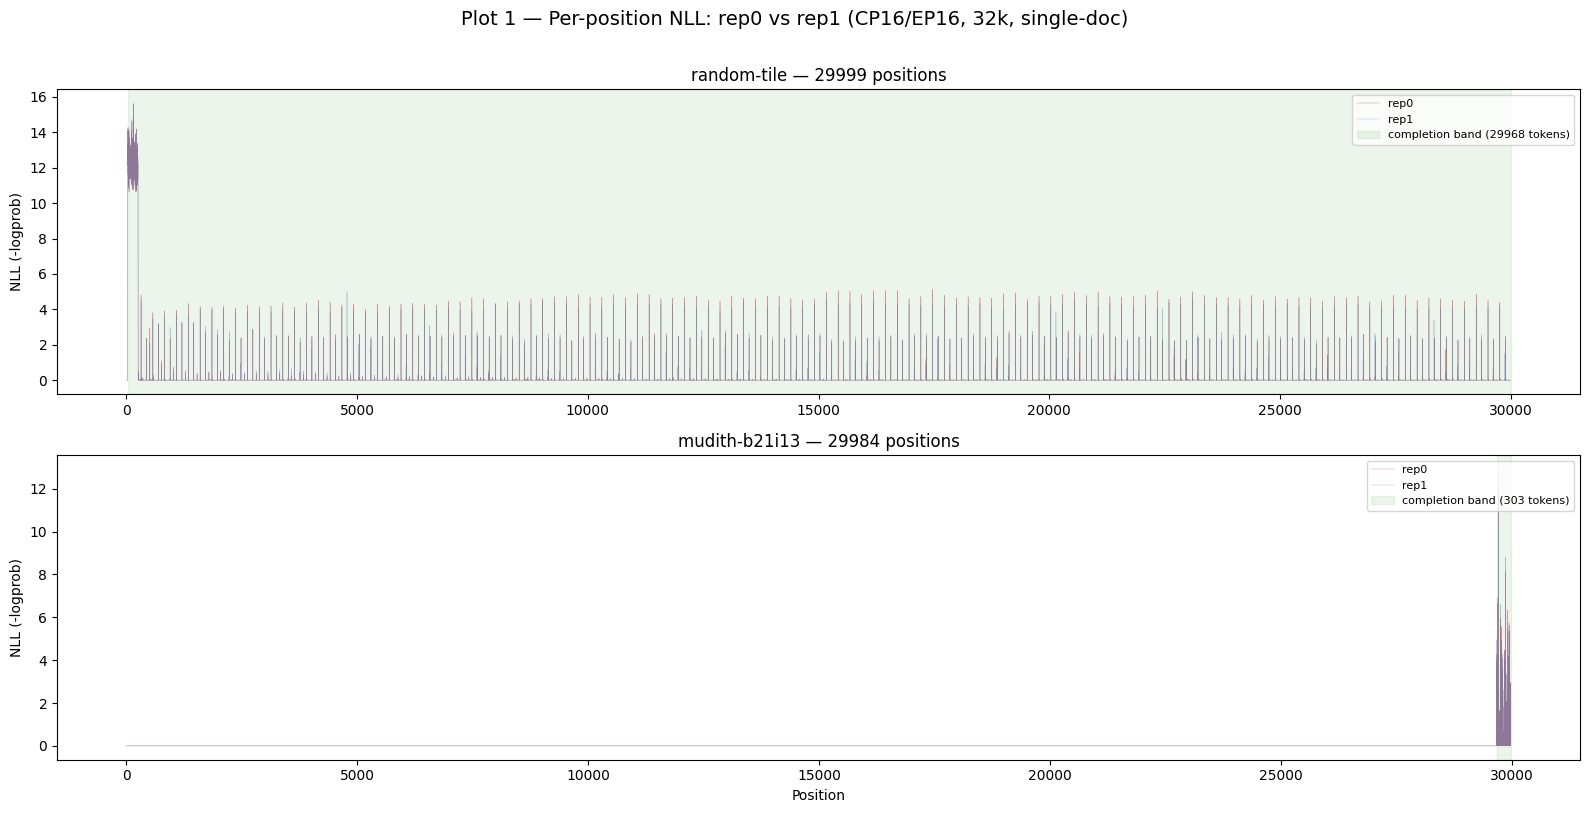

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    x = np.arange(len(nll0))
    s = SUPERVISED[di]

    ax.plot(x, nll0, color='#C44E52', linewidth=0.3, alpha=0.7, label='rep0')
    ax.plot(x, nll1, color='#4C72B0', linewidth=0.3, alpha=0.5, label='rep1')

    # Mark completion band
    if s['n'] < len(nll0):
        ax.axvspan(s['start'], s['end'], alpha=0.08, color='green', label=f"completion band ({s['n']} tokens)")

    ax.set_ylabel('NLL (-logprob)')
    ax.set_title(f'{DATUM_LABELS[di]} — {len(nll0)} positions')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 1 — Per-position NLL: rep0 vs rep1 (CP16/EP16, 32k, single-doc)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Plot 2 — Per-rep NLL bar chart (weighted, supervised tokens only)


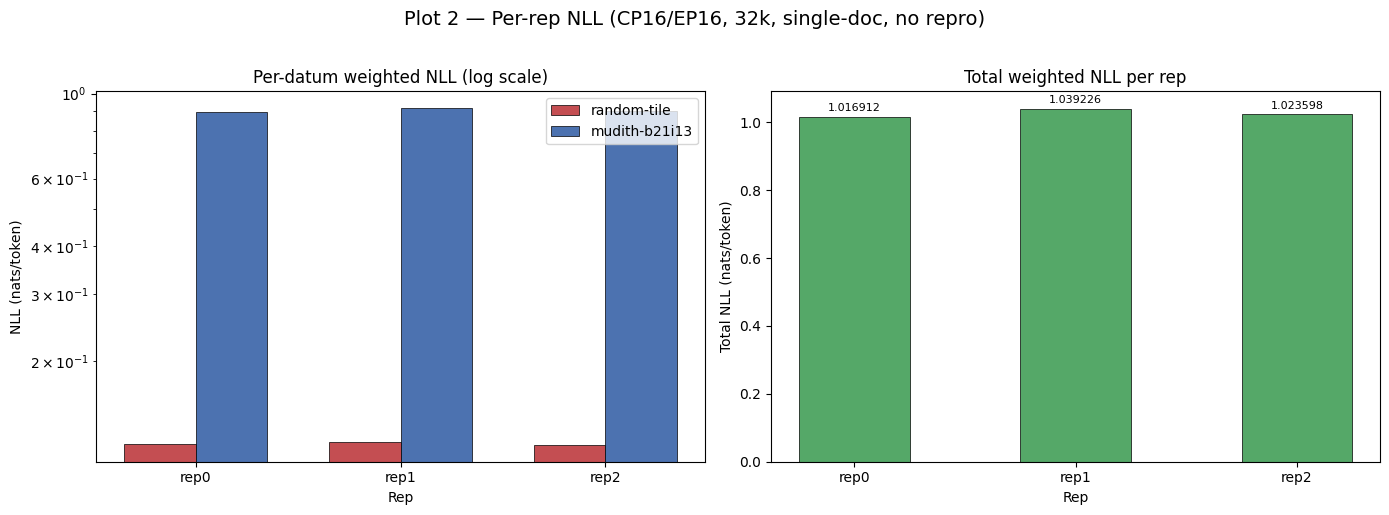

In [3]:
n_datums = len(reps[0]['nlls'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(N_REPS)
width = 0.35
colors = ['#C44E52', '#4C72B0']

for di in range(n_datums):
    vals = [reps[r]['nlls'][di] for r in range(N_REPS)]
    offset = (di - n_datums/2 + 0.5) * width
    ax1.bar(x + offset, vals, width, label=DATUM_LABELS[di],
            color=colors[di], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Rep')
ax1.set_ylabel('NLL (nats/token)')
ax1.set_title('Per-datum weighted NLL (log scale)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
ax1.set_yscale('log')
ax1.legend()

totals = [sum(reps[r]['nlls']) for r in range(N_REPS)]
bars = ax2.bar(x, totals, width=0.5, color='#55A868', edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Rep')
ax2.set_ylabel('Total NLL (nats/token)')
ax2.set_title('Total weighted NLL per rep')
ax2.set_xticks(x)
ax2.set_xticklabels([f'rep{r}' for r in range(N_REPS)])
for bar, val in zip(bars, totals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:.6f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Plot 2 — Per-rep NLL (CP16/EP16, 32k, single-doc, no repro)', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (both datums, full sequence)


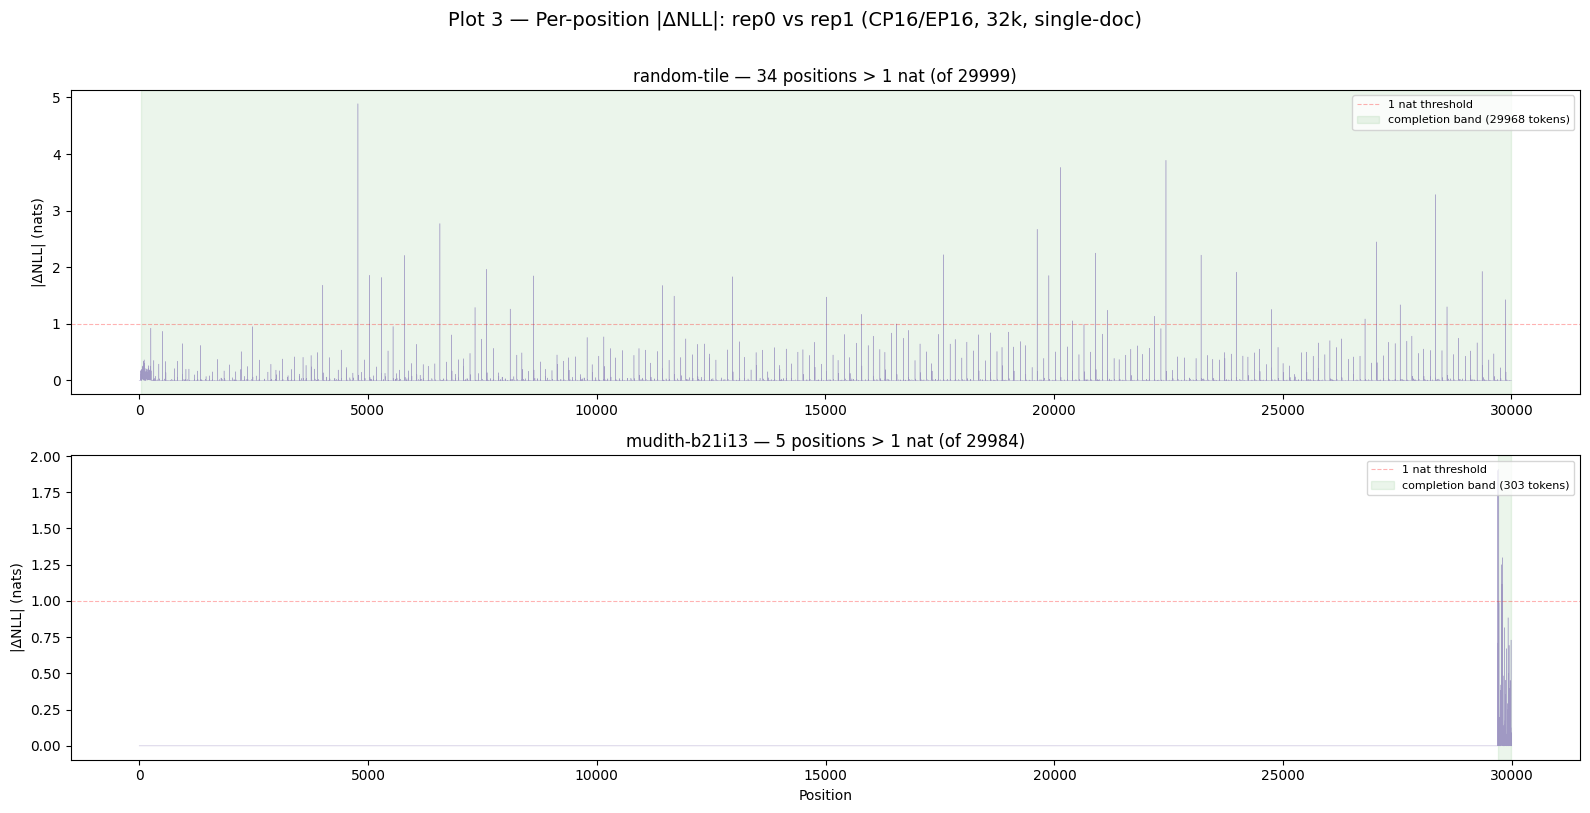

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for di, ax in enumerate(axes):
    nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
    nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
    delta = np.abs(nll0 - nll1)
    x = np.arange(len(delta))
    s = SUPERVISED[di]

    ax.plot(x, delta, color='#8172B3', linewidth=0.3, alpha=0.7)
    ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
    if s['n'] < len(delta):
        ax.axvspan(s['start'], s['end'], alpha=0.08, color='green', label=f"completion band ({s['n']} tokens)")

    n_big = int((delta > 1.0).sum())
    ax.set_ylabel('|ΔNLL| (nats)')
    ax.set_title(f'{DATUM_LABELS[di]} — {n_big} positions > 1 nat (of {len(delta)})')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position')
fig.suptitle('Plot 3 — Per-position |ΔNLL|: rep0 vs rep1 (CP16/EP16, 32k, single-doc)', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Plot 3 zoom — mudith-b21i13 completion band [29681..29983]


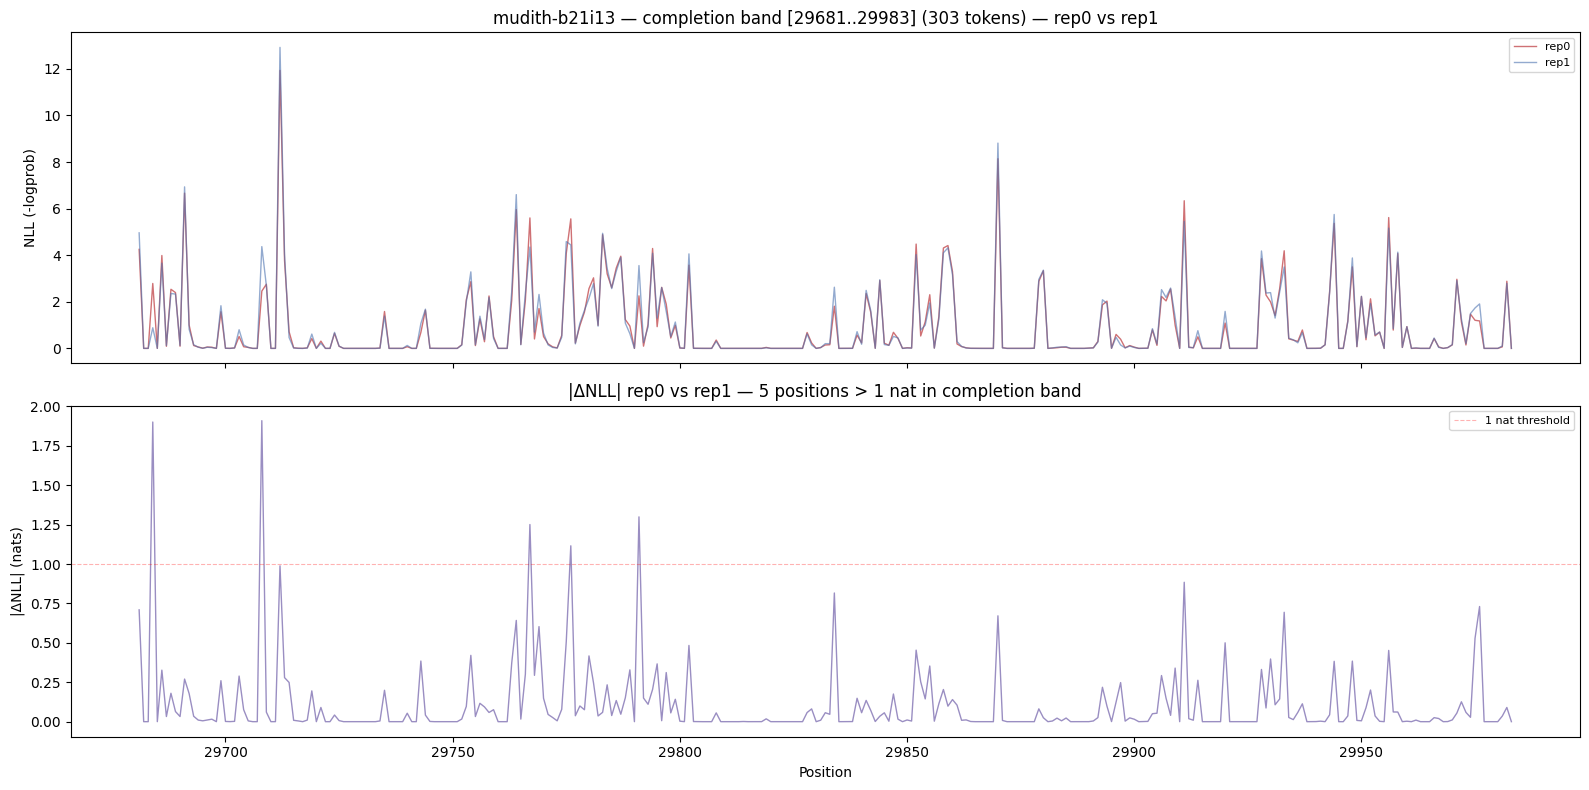

In [5]:
di = 1  # mudith-b21i13
s = SUPERVISED[di]
lo, hi = s['start'], s['end']

nll0 = -np.array(reps[0]['logprobs'][di], dtype=np.float64)
nll1 = -np.array(reps[1]['logprobs'][di], dtype=np.float64)
delta = np.abs(nll0 - nll1)
x = np.arange(len(delta))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.plot(x[lo:hi+1], nll0[lo:hi+1], color='#C44E52', linewidth=1.0, alpha=0.8, label='rep0')
ax.plot(x[lo:hi+1], nll1[lo:hi+1], color='#4C72B0', linewidth=1.0, alpha=0.6, label='rep1')
ax.set_ylabel('NLL (-logprob)')
ax.set_title(f'{DATUM_LABELS[di]} — completion band [{lo}..{hi}] ({s["n"]} tokens) — rep0 vs rep1')
ax.legend(loc='upper right', fontsize=8)

ax = axes[1]
ax.plot(x[lo:hi+1], delta[lo:hi+1], color='#8172B3', linewidth=1.0, alpha=0.8)
ax.axhline(1.0, color='red', alpha=0.3, linestyle='--', linewidth=0.8, label='1 nat threshold')
n_big = int((delta[lo:hi+1] > 1.0).sum())
ax.set_ylabel('|ΔNLL| (nats)')
ax.set_xlabel('Position')
ax.set_title(f'|ΔNLL| rep0 vs rep1 — {n_big} positions > 1 nat in completion band')
ax.legend(loc='upper right', fontsize=8)

fig.tight_layout()
plt.show()

### Summary — weighted NLL (supervised tokens only)

| datum | rep0 | rep1 | rep2 | max|ΔNLL| vs rep0 |
|---|---|---|---|---|


In [6]:
for di in range(len(reps[0]['nlls'])):
    label = DATUM_LABELS[di] if di < len(DATUM_LABELS) else f'd{di}'
    row = [reps[r]['nlls'][di] for r in range(N_REPS)]
    rest = row[1:]
    dmax = max(abs(row[0] - v) for v in rest) if rest else 0.0
    print(f'{label:<16}' + ''.join(f'{v:<12.6f}' for v in row) + f'{dmax:.6f}')
print()
print('VERDICT: clean — no rep0-vs-rest destruction above 2 nats')

random-tile     0.121787    0.123366    0.121124    0.001579
mudith-b21i13   0.895125    0.915860    0.902474    0.020735

VERDICT: clean — no rep0-vs-rest destruction above 2 nats
